<a href="https://colab.research.google.com/github/HafidzShahab/Data-Science_240401020180_AhmadHafidz/blob/main/pertemuan11_%5BAhmad_Hafidz%5D__%5B240401020180%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* **Nama** : Ahmad Hafidz
* **NIM** : 240401020180
* **Kelas** : IF 401

Ukuran Dataset (Shape): (300, 4)

--- Statistik Deskriptif ---
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


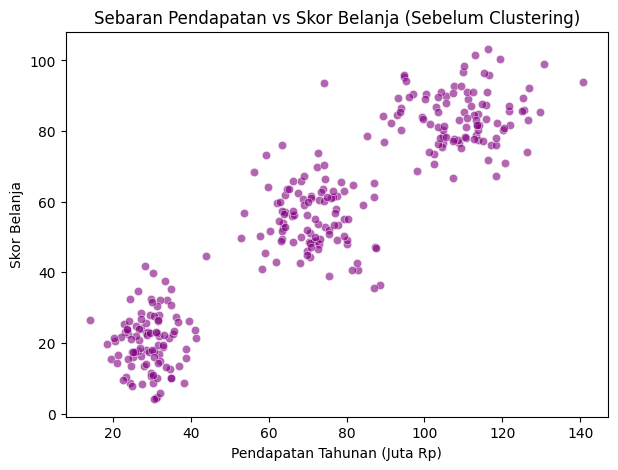

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed agar hasil random selalu sama
np.random.seed(42)

# Menghasilkan 3 kelompok data tersembunyi
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # Karakteristik: Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # Karakteristik: Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # Karakteristik: Boros/Premium
data = np.vstack([grp1, grp2, grp3])

# Membuat DataFrame
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

# Menampilkan informasi dasar data
print('Ukuran Dataset (Shape):', df.shape)
print("\n--- Statistik Deskriptif ---")
print(df.describe().round(2))

# Visualisasi sebaran data awal
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='purple')
plt.title('Sebaran Pendapatan vs Skor Belanja (Sebelum Clustering)')
plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja')
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur numerik yang akan digunakan untuk clustering
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Menerapkan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling (mendekati 0):', X_scaled.mean(axis=0).round(3))
print('Standar deviasi setelah scaling (mendekati 1):', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling (mendekati 0): [-0.  0.]
Standar deviasi setelah scaling (mendekati 1): [1. 1.]


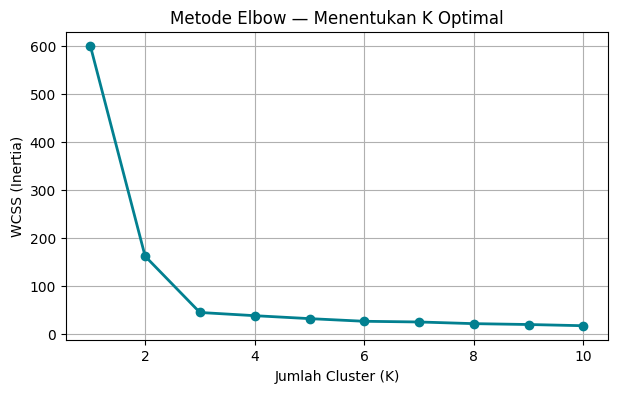

In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot grafik Elbow
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linewidth=2)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Metode Elbow — Menentukan K Optimal')
plt.grid(True)
plt.show()

In [4]:
from sklearn.metrics import silhouette_score

# Melatih model dengan K=3
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)

# Menyimpan label cluster ke DataFrame asal
df['cluster'] = model.labels_

print(f'WCSS Akhir (Inertia): {model.inertia_:.3f}')
print(f'Silhouette Score     : {silhouette_score(X_scaled, model.labels_):.3f}')

print("\n--- Rata-rata Fitur per Cluster ---")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja', 'usia']].mean().round(2))

WCSS Akhir (Inertia): 44.556
Silhouette Score     : 0.695

--- Rata-rata Fitur per Cluster ---
         pendapatan_tahunan  skor_belanja   usia
cluster                                         
0                     70.99         55.05  39.16
1                     29.31         20.27  42.33
2                    109.20         84.08  44.65


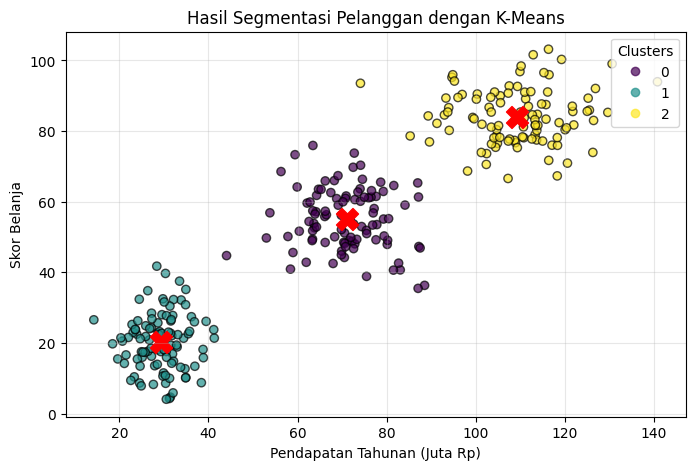

In [5]:
# Mengembalikan posisi centroid ke skala asli (sebelum scaling)
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 5))
# Plot data berdasarkan label clusternya
scatter = plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                      c=df['cluster'], cmap='viridis', alpha=0.7, edgecolors='k')

# Plot titik centroid
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250, label='Centroid')

plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Hasil Segmentasi Pelanggan dengan K-Means')
plt.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
plt.grid(alpha=0.3)
plt.show()

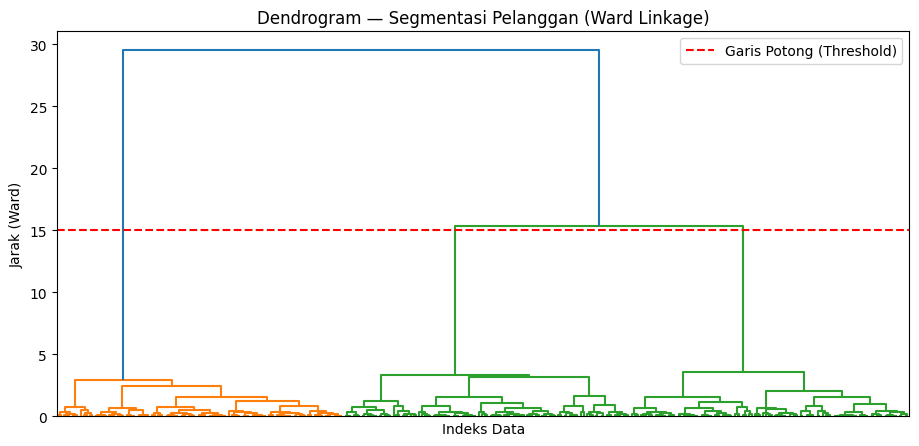

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Menghitung linkage matrix menggunakan metode Ward
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(11, 5))
dendrogram(Z, no_labels=True) # no_labels=True agar sumbu X tidak penuh dengan indeks data
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')

# Membuat garis potong horizontal sebagai batas penentu jumlah cluster
plt.axhline(y=15, color='red', linestyle='--', label='Garis Potong (Threshold)')
plt.legend()
plt.show()

Berdasarkan aktivitas hands-on yang dilakukan, dapat disimpulkan bahwa algoritma K-Means berhasil mengidentifikasi tiga segmen pelanggan secara alami, yaitu kelompok 'Hemat', 'Menengah', dan 'Boros/Premium' berdasarkan fitur pendapatan tahunan dan skor belanja mereka. Penentuan jumlah cluster ($K=3$) ini divalidasi secara akurat melalui Metode Elbow yang menunjukkan titik siku melandai pada angka tiga, serta diperkuat oleh nilai Silhouette Score yang mendekati +1 yang menandakan kualitas pengelompokan yang sangat rapat dan terpisah dengan baik. Terakhir, hasil visualisasi Dendrogram pada Hierarchical Clustering menunjukkan konsistensi yang sama dengan memotong tiga garis vertikal utama, membuktikan bahwa struktur pengelompokan pelanggan pada dataset ini sangat stabil dan objektif.